In [12]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
import matplotlib.pyplot as plt

# Suppress warnings for clear output
import warnings
warnings.filterwarnings('ignore')

In [9]:
# Assuming test data (X_test, y_test) and trained model saved as "best_lstm_model.keras"
# Load test features and labels
X = np.load("../../milestone_3/data/rolling_window_sequences.npy")  # Replace with actual file path
metadata_test = pd.read_csv("../../milestone_3/data/sequence_metadata_with_RUL.csv")  # Replace with actual file path
y = metadata_test["RUL"].values

print("Test feature shape:", X.shape)
print("Test target shape:", y.shape)

# Load trained LSTM model
model = tf.keras.models.load_model("../../milestone_2/day_2/best_lstm_model.keras")  # Replace with actual file path

Test feature shape: (17631, 30, 66)
Test target shape: (17631,)


In [13]:
y_pred = model.predict(X)
y_pred = y_pred.flatten()

y_pred.shape

551/551 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step


(17631,)

In [14]:
# Calculate RMSE and MAE
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae = mean_absolute_error(y, y_pred)

print(f"RMSE: {rmse}")
print(f"MAE: {mae}")

RMSE: 4.373984846421638
MAE: 3.0330713610270204


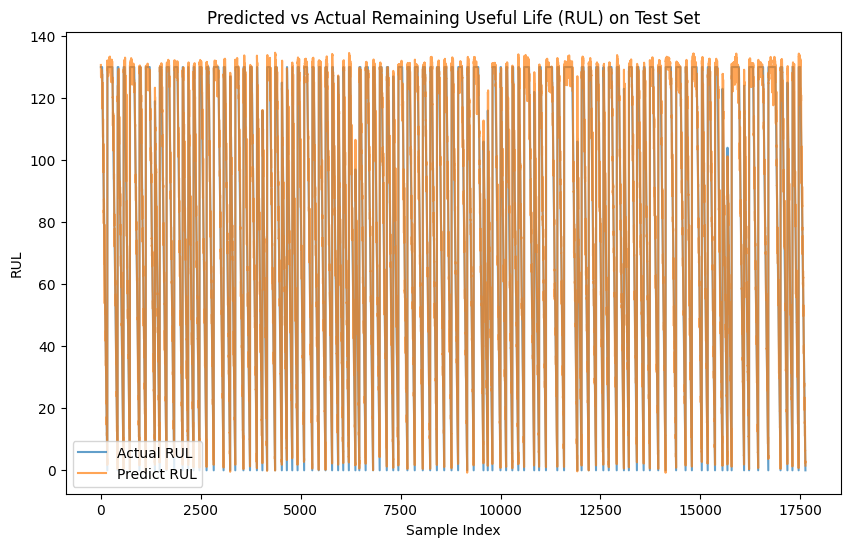

In [15]:
# Visualize Actual vs Predict RUL
plt.figure(figsize=(10, 6))
plt.plot(y, label='Actual RUL', alpha=0.7)
plt.plot(y_pred, label='Predict RUL', alpha=0.7)
plt.title('Predicted vs Actual Remaining Useful Life (RUL) on Test Set')
plt.xlabel('Sample Index')
plt.ylabel('RUL')
plt.legend()
plt.show()